# 🏟️ Football Score Prediction — Competition Pipeline

Pipeline end-to-end untuk memprediksi `team_goals` dan `opp_goals`, dirancang berdasarkan insight dari EDA:

| Insight EDA | Implementasi Pipeline |
|---|---|
| Format 2-row per match (mirror target) | Model simetris, satu untuk tiap target |
| ELO & form features tidak tersedia di test | Rekonstruksi dari train terakhir |
| Train-test gap: 2011 → 2026 | Validasi time-based + smoothed encodings |
| Gender shift: W naik dari 11% → 33% | Gender sebagai fitur utama |
| Distribusi Poisson (count data) | LightGBM & XGBoost dengan objective Poisson |
| Rank & ELO sangat prediktif | Prioritas fitur strength & form |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder

import gc, json
from copy import deepcopy

SEED = 42
np.random.seed(SEED)

print("LightGBM:", lgb.__version__)
print("XGBoost:", xgb.__version__)


LightGBM: 4.6.0
XGBoost: 3.1.2


## 1. Data Loading & Basic Preprocessing

In [2]:
# ------------------------------------------------------------------
# Adjust DATA_PATH jika file tidak di direktori yang sama
# ------------------------------------------------------------------
DATA_PATH = Path("../dataset")

train = pd.read_csv(DATA_PATH / "train.csv")
test  = pd.read_csv(DATA_PATH / "test.csv")

# ----- parse dates & clean sentinel -----
for df in [train, test]:
    df["date"]           = pd.to_datetime(df["date"])
    df["year"]           = df["date"].dt.year
    df["month"]          = df["date"].dt.month
    df["dayofyear"]      = df["date"].dt.dayofyear
    df["altitude_venue"] = df["altitude_venue"].replace(-9999, np.nan)

# Sort by date (critical for temporal operations)
train = train.sort_values(["date", "match_id"]).reset_index(drop=True)
test  = test.sort_values(["date", "match_id"]).reset_index(drop=True)

print(f"Train : {train.shape}  |  {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Test  : {test.shape}  |  {test['date'].min().date()} → {test['date'].max().date()}")
print()
print("Target distribution (train):")
print(train[["team_goals", "opp_goals"]].describe().T[["mean","std","min","50%","max"]].round(3))


Train : (78772, 50)  |  1872-11-30 → 2011-08-04
Test  : (42422, 23)  |  2011-08-06 → 2026-03-31

Target distribution (train):
             mean    std  min  50%   max
team_goals  1.563  1.792  0.0  1.0  31.0
opp_goals   1.563  1.792  0.0  1.0  31.0


## 2. Rekonstruksi Fitur Train-Only untuk Test

EDA menunjukkan bahwa ELO, rank, dan form features adalah fitur paling prediktif — tetapi semuanya hanya ada di train.
Strategi: ambil nilai terakhir yang diketahui tiap tim dari train, lalu aplikasikan ke test.


In [3]:
# ================================================================
# 2A. ELO Reconstruction
#     Setiap tim memiliki ELO terakhir yang diketahui di train.
#     Untuk test (2011-2026), kita gunakan nilai ini sebagai proxy.
# ================================================================

GLOBAL_ELO_MEAN = train["elo_team"].mean()

# Ambil ELO terakhir per tim (perspektif "team")
last_elo_as_team = (
    train.sort_values("date")
         .groupby("team")["elo_team"]
         .last()
)
# Tambahkan perspektif "opponent"
last_elo_as_opp = (
    train.sort_values("date")
         .groupby("opponent")["elo_opponent"]
         .last()
)
# Merge: tim yang tidak muncul sebagai "team" mungkin ada sebagai "opponent"
elo_lookup = last_elo_as_opp.to_dict()
elo_lookup.update(last_elo_as_team.to_dict())   # team perspective overrides

# Apply ke test
test["elo_team"]     = test["team"].map(elo_lookup).fillna(GLOBAL_ELO_MEAN)
test["elo_opponent"] = test["opponent"].map(elo_lookup).fillna(GLOBAL_ELO_MEAN)

print("ELO reconstruction:")
print(f"  test elo_team     null: {test['elo_team'].isna().sum()}")
print(f"  test elo_opponent null: {test['elo_opponent'].isna().sum()}")
print(f"  Global ELO mean  : {GLOBAL_ELO_MEAN:.1f}")


ELO reconstruction:
  test elo_team     null: 0
  test elo_opponent null: 0
  Global ELO mean  : 1569.4


In [4]:
# ================================================================
# 2B. Rank Reconstruction
# ================================================================

GLOBAL_RANK_MEDIAN = train["rank_team"].median()

last_rank_team = (
    train[train["rank_team"].notna()]
         .sort_values("date")
         .groupby("team")["rank_team"]
         .last()
)
last_rank_opp = (
    train[train["rank_opponent"].notna()]
         .sort_values("date")
         .groupby("opponent")["rank_opponent"]
         .last()
)
rank_lookup = last_rank_opp.to_dict()
rank_lookup.update(last_rank_team.to_dict())

test["rank_team"]         = test["team"].map(rank_lookup).fillna(GLOBAL_RANK_MEDIAN)
test["rank_opponent"]     = test["opponent"].map(rank_lookup).fillna(GLOBAL_RANK_MEDIAN)
test["rank_missing_team"] = test["team"].map(rank_lookup).isna().astype(int)
test["rank_missing_opp"]  = test["opponent"].map(rank_lookup).isna().astype(int)
test["rank_diff"]         = test["rank_team"] - test["rank_opponent"]

# Fill train missing ranks (beberapa baris awal bisa kosong)
for df in [train]:
    df["rank_team"]     = df["rank_team"].fillna(df["team"].map(rank_lookup)).fillna(GLOBAL_RANK_MEDIAN)
    df["rank_opponent"] = df["rank_opponent"].fillna(df["opponent"].map(rank_lookup)).fillna(GLOBAL_RANK_MEDIAN)
    df["rank_diff"]     = df["rank_team"] - df["rank_opponent"]

print("Rank reconstruction done.")
print(f"  test rank_team null: {test['rank_team'].isna().sum()}")


Rank reconstruction done.
  test rank_team null: 0


In [5]:
# ================================================================
# 2C. Form Features (Last-5 / Last-10 per team)
#     Untuk test, gunakan last-N dari train sebagai proxy.
# ================================================================

def compute_form_lookup(df, n):
    """
    Hitung rata-rata form stats dari N match terakhir tiap tim di df.
    Return: DataFrame indexed by team name.
    """
    df_s = df.sort_values("date").copy()
    df_s["win"]    = (df_s["team_goals"] > df_s["opp_goals"]).astype(float)
    df_s["draw"]   = (df_s["team_goals"] == df_s["opp_goals"]).astype(float)
    df_s["points"] = df_s["win"] * 3 + df_s["draw"]
    df_s["gd"]     = df_s["team_goals"] - df_s["opp_goals"]

    last_n = df_s.groupby("team", group_keys=False).tail(n)

    stats = last_n.groupby("team").agg(
        avg_goals      = ("team_goals", "mean"),
        avg_conceded   = ("opp_goals",  "mean"),
        win_rate       = ("win",        "mean"),
        points_sum     = ("points",     "sum"),
        avg_gd         = ("gd",         "mean"),
    )
    return stats


# Compute for last 5 and last 10 matches
form5  = compute_form_lookup(train, n=5)
form10 = compute_form_lookup(train, n=10)

GLOBAL_AVG_GOALS = train["team_goals"].mean()
GLOBAL_WIN_RATE  = (train["team_goals"] > train["opp_goals"]).mean()

def map_form_to_df(df, team_col, form5, form10, prefix):
    """Map form stats to df[team_col] with given prefix."""
    df[f"{prefix}_avg_goals_last5"]    = df[team_col].map(form5["avg_goals"]).fillna(GLOBAL_AVG_GOALS)
    df[f"{prefix}_avg_conceded_last5"] = df[team_col].map(form5["avg_conceded"]).fillna(GLOBAL_AVG_GOALS)
    df[f"{prefix}_win_rate_last10"]    = df[team_col].map(form10["win_rate"]).fillna(GLOBAL_WIN_RATE)
    df[f"{prefix}_points_last5"]       = df[team_col].map(form5["points_sum"]).fillna(0)
    df[f"{prefix}_gd_last5"]           = df[team_col].map(form5["avg_gd"]).fillna(0)
    df[f"{prefix}_points_last10"]      = df[team_col].map(form10["points_sum"]).fillna(0)
    return df

# Apply to test
test = map_form_to_df(test, "team",     form5, form10, "team_rec")
test = map_form_to_df(test, "opponent", form5, form10, "opp_rec")

# For train: fitur aslinya sudah ada tapi kita tambahkan versi rekonstruksi
# sebagai fallback untuk baris yang missing (match awal)
train["team_avg_goals_last5"]    = train["team_avg_goals_last5"].fillna(train["team"].map(form5["avg_goals"])).fillna(GLOBAL_AVG_GOALS)
train["team_avg_conceded_last5"] = train["team_avg_conceded_last5"].fillna(train["team"].map(form5["avg_conceded"])).fillna(GLOBAL_AVG_GOALS)
train["opp_avg_goals_last5"]     = train["opp_avg_goals_last5"].fillna(train["opponent"].map(form5["avg_goals"])).fillna(GLOBAL_AVG_GOALS)
train["opp_avg_conceded_last5"]  = train["opp_avg_conceded_last5"].fillna(train["opponent"].map(form5["avg_conceded"])).fillna(GLOBAL_AVG_GOALS)
train["team_win_rate_last10"]    = train["team_win_rate_last10"].fillna(train["team"].map(form10["win_rate"])).fillna(GLOBAL_WIN_RATE)
train["opp_win_rate_last10"]     = train["opp_win_rate_last10"].fillna(train["opponent"].map(form10["win_rate"])).fillna(GLOBAL_WIN_RATE)
train["team_points_last5"]       = train["team_points_last5"].fillna(0)
train["opp_points_last5"]        = train["opp_points_last5"].fillna(0)
train["h2h_points_last5"]        = train["h2h_points_last5"].fillna(0)
train["h2h_gd_last5"]            = train["h2h_gd_last5"].fillna(0)

print("Form features done.")
print(f"  test team_rec_avg_goals_last5 null: {test['team_rec_avg_goals_last5'].isna().sum()}")


Form features done.
  test team_rec_avg_goals_last5 null: 0


In [6]:
# ================================================================
# 2D. Head-to-Head Features & Days Since Last Match
# ================================================================

# --- H2H lookup ---
train_h2h = train.sort_values("date").copy()
train_h2h["win"]    = (train_h2h["team_goals"] > train_h2h["opp_goals"]).astype(float)
train_h2h["draw"]   = (train_h2h["team_goals"] == train_h2h["opp_goals"]).astype(float)
train_h2h["points"] = train_h2h["win"] * 3 + train_h2h["draw"]
train_h2h["gd"]     = train_h2h["team_goals"] - train_h2h["opp_goals"]
train_h2h["pair"]   = train_h2h["team"] + "|||" + train_h2h["opponent"]

h2h_last5 = (
    train_h2h.groupby("pair", group_keys=False)
              .tail(5)
              .groupby("pair")
              .agg(
                  h2h_pts5       = ("points", "sum"),
                  h2h_gd5        = ("gd",     "mean"),
                  h2h_avg_goals  = ("team_goals",  "mean"),
                  h2h_avg_conc   = ("opp_goals",   "mean"),
                  h2h_n_matches  = ("gd",           "count"),
              )
)

# Map to test
test["pair"] = test["team"] + "|||" + test["opponent"]
for col in ["h2h_pts5", "h2h_gd5", "h2h_avg_goals", "h2h_avg_conc", "h2h_n_matches"]:
    test[col] = test["pair"].map(h2h_last5[col]).fillna(0 if "pts" in col or "gd" in col or "n_" in col else GLOBAL_AVG_GOALS)

# Also add to train (supplement existing h2h columns)
train["pair"] = train["team"] + "|||" + train["opponent"]
train["h2h_avg_goals"] = train["pair"].map(h2h_last5["h2h_avg_goals"]).fillna(GLOBAL_AVG_GOALS)
train["h2h_avg_conc"]  = train["pair"].map(h2h_last5["h2h_avg_conc"]).fillna(GLOBAL_AVG_GOALS)

# --- Days since last match ---
last_match_date = (
    train.sort_values("date")
         .groupby("team")["date"]
         .last()
)

def compute_days_since(df, lookup_col="team"):
    last_date_map = last_match_date.to_dict()
    days = df.apply(
        lambda r: (r["date"] - last_date_map.get(r[lookup_col], r["date"])).days
        if r[lookup_col] in last_date_map else np.nan,
        axis=1
    )
    return days.clip(lower=0).fillna(0)

test["days_since_last_team"] = compute_days_since(test, "team")
test["days_since_last_opp"]  = compute_days_since(test, "opponent")

# Fill train days_since missing
train["days_since_last_match_team"] = train["days_since_last_match_team"].fillna(0)
train["days_since_last_match_opp"]  = train["days_since_last_match_opp"].fillna(0)

print("H2H & days_since done.")


H2H & days_since done.


## 3. Advanced Feature Engineering

In [7]:
# ================================================================
# Feature Engineering — berlaku untuk train dan test
# ================================================================

def engineer_features(df):
    """
    Membuat fitur-fitur turunan berdasarkan insight EDA.
    Input: DataFrame dengan semua kolom yang sudah di-reconstruct.
    Output: DataFrame dengan kolom baru.
    """
    out = df.copy()

    # ---- 1. ELO Derived ----
    out["elo_diff"]     = out["elo_team"] - out["elo_opponent"]
    out["elo_win_prob"] = 1 / (1 + 10 ** (-out["elo_diff"] / 400))   # Dixon-Coles win prob
    out["elo_team_log"] = np.log(out["elo_team"].clip(lower=100))
    out["elo_opp_log"]  = np.log(out["elo_opponent"].clip(lower=100))

    # ---- 2. Rank Derived ----
    out["rank_diff"]  = out["rank_team"] - out["rank_opponent"]
    out["rank_ratio"] = out["rank_team"] / (out["rank_opponent"] + 1)
    # Lower rank = better team, so negative rank_diff = team is better
    out["rank_advantage"] = -out["rank_diff"]   # positive = team is higher ranked

    # ---- 3. Form Derived ----
    # Pilih kolom form yang tersedia (train punya kolom asli, test punya "_rec")
    def get_form_col(df, name, rec_name, fallback):
        """Gunakan kolom asli jika tersedia, fallback ke rekonstruksi."""
        if name in df.columns:
            return df[name].fillna(df.get(rec_name, pd.Series(fallback, index=df.index)))
        return df.get(rec_name, pd.Series(fallback, index=df.index))

    out["f_team_atk"]  = get_form_col(out, "team_avg_goals_last5",   "team_rec_avg_goals_last5",   GLOBAL_AVG_GOALS)
    out["f_team_def"]  = get_form_col(out, "team_avg_conceded_last5", "team_rec_avg_conceded_last5",GLOBAL_AVG_GOALS)
    out["f_opp_atk"]   = get_form_col(out, "opp_avg_goals_last5",    "opp_rec_avg_goals_last5",    GLOBAL_AVG_GOALS)
    out["f_opp_def"]   = get_form_col(out, "opp_avg_conceded_last5",  "opp_rec_avg_conceded_last5", GLOBAL_AVG_GOALS)
    out["f_team_wr"]   = get_form_col(out, "team_win_rate_last10",    "team_rec_win_rate_last10",   GLOBAL_WIN_RATE)
    out["f_opp_wr"]    = get_form_col(out, "opp_win_rate_last10",     "opp_rec_win_rate_last10",    GLOBAL_WIN_RATE)

    # Expected goals based on attack vs defense
    out["xg_team"]    = (out["f_team_atk"] + out["f_opp_def"]) / 2   # expected goals team scores
    out["xg_opp"]     = (out["f_opp_atk"]  + out["f_team_def"]) / 2  # expected goals opp scores
    out["xg_total"]   = out["xg_team"] + out["xg_opp"]
    out["xg_diff"]    = out["xg_team"] - out["xg_opp"]
    out["form_advantage"] = out["f_team_wr"] - out["f_opp_wr"]

    # ---- 4. H2H Derived ----
    h2h_gd_col = "h2h_gd_last5" if "h2h_gd_last5" in out.columns else "h2h_gd5"
    h2h_pt_col = "h2h_points_last5" if "h2h_points_last5" in out.columns else "h2h_pts5"
    out["h2h_gd"]  = out.get(h2h_gd_col, pd.Series(0.0, index=out.index)).fillna(0)
    out["h2h_pts"] = out.get(h2h_pt_col, pd.Series(0.0, index=out.index)).fillna(0)
    out["h2h_avg_goals_fe"]  = out.get("h2h_avg_goals",  pd.Series(GLOBAL_AVG_GOALS, index=out.index)).fillna(GLOBAL_AVG_GOALS)
    out["h2h_avg_conc_fe"]   = out.get("h2h_avg_conc",   pd.Series(GLOBAL_AVG_GOALS, index=out.index)).fillna(GLOBAL_AVG_GOALS)

    # ---- 5. Home Advantage ----
    out["effective_home"] = out["is_home"] * (1 - out["neutral"])   # 1 only if truly home (not neutral)
    out["home_advantage"] = out["effective_home"].astype(float)

    # ---- 6. Environmental ----
    alt = out["altitude_venue"].fillna(0).clip(lower=0)
    out["altitude_log"]  = np.log1p(alt)
    out["is_high_alt"]   = (out["altitude_venue"].fillna(0) > 1500).astype(int)
    out["temp_fill"]     = out["temperature_venue"].fillna(out["temperature_venue"].median() if "temperature_venue" in out else 20)
    out["temp_extreme"]  = (out["temp_fill"] - 20).abs()
    out["dist_team_log"] = np.log1p(out["distance_travel_team"].fillna(0))
    out["dist_opp_log"]  = np.log1p(out["distance_travel_opp"].fillna(0))
    out["dist_diff"]     = out["dist_team_log"] - out["dist_opp_log"]

    # ---- 7. Economic / Demographic ----
    gdp_t = out["gdp_per_capita_team"].fillna(out["gdp_per_capita_team"].median() if "gdp_per_capita_team" in out else 10000).clip(lower=1)
    gdp_o = out["gdp_per_capita_opp"].fillna(out["gdp_per_capita_opp"].median() if "gdp_per_capita_opp" in out else 10000).clip(lower=1)
    pop_t = out["population_team"].fillna(out["population_team"].median() if "population_team" in out else 1e7).clip(lower=1)
    pop_o = out["population_opp"].fillna(out["population_opp"].median() if "population_opp" in out else 1e7).clip(lower=1)

    out["log_gdp_team"]  = np.log1p(gdp_t)
    out["log_gdp_opp"]   = np.log1p(gdp_o)
    out["gdp_ratio"]     = out["log_gdp_team"] - out["log_gdp_opp"]
    out["log_pop_team"]  = np.log1p(pop_t)
    out["log_pop_opp"]   = np.log1p(pop_o)
    out["pop_ratio"]     = out["log_pop_team"] - out["log_pop_opp"]

    # ---- 8. Temporal ----
    out["gender_num"] = (out["gender"] == "W").astype(int)
    out["era"]        = pd.cut(out["year"],
                               bins=[1870, 1949, 1989, 2000, 2010, 2030],
                               labels=[0, 1, 2, 3, 4]).astype(float)
    out["is_modern"]  = (out["year"] >= 1990).astype(int)

    return out


train_fe = engineer_features(train)
test_fe  = engineer_features(test)

print("Feature engineering done.")
print(f"Train FE shape: {train_fe.shape}")
print(f"Test  FE shape: {test_fe.shape}")


Feature engineering done.
Train FE shape: (78772, 92)
Test  FE shape: (42422, 89)


## 4. Target Encoding (Smoothed)

Untuk menangkap kekuatan tim, turnamen, dan konfederasi, kita gunakan **smoothed target encoding**.
Untuk menghindari data leakage pada train, kita gunakan **Leave-One-Out encoding** pada fold CV,
dan full-train statistics untuk test.


In [8]:
# ================================================================
# Smoothed Target Encoding — computed from FULL train
# (akan digunakan untuk test dan sebagai global fallback di train)
# ================================================================

def build_smooth_te(train_df, col, target, alpha=20):
    """
    Smoothed (James-Stein) target encoding.
    alpha: regularization strength (higher = more smoothing toward global mean).
    """
    global_mean = train_df[target].mean()
    stats = train_df.groupby(col)[target].agg(["count", "mean"])
    stats["smooth"] = (
        (stats["count"] * stats["mean"] + alpha * global_mean)
        / (stats["count"] + alpha)
    )
    return stats["smooth"].to_dict(), global_mean


# Columns to encode and their mapping keys
TE_CONFIGS = [
    ("team",              "team",        "team_goals"),
    ("opponent",          "opponent",    "team_goals"),    # how much opp concedes when they're "opponent"
    ("tournament",        "tournament",  "team_goals"),
    ("confederation_team","confederation_team", "team_goals"),
    ("confederation_opp", "confederation_opp",  "team_goals"),
    ("team",              "team",        "opp_goals"),
    ("opponent",          "opponent",    "opp_goals"),
]

te_maps = {}   # will store (col, target) -> (mapping_dict, global_mean)

for col, map_col, target in TE_CONFIGS:
    key = f"{col}__{target}"
    if key not in te_maps:
        mapping, gm = build_smooth_te(train_fe, col, target)
        te_maps[key] = (mapping, gm, map_col)

# Apply to test (no leakage concern)
for key, (mapping, gm, map_col) in te_maps.items():
    col, target = key.split("__")
    feat_name = f"te_{col}_{target}"
    test_fe[feat_name]  = test_fe[map_col].map(mapping).fillna(gm)
    train_fe[feat_name] = train_fe[map_col].map(mapping).fillna(gm)

# ---- Opponent-as-defender encoding ----
# How many goals does this "opponent" typically concede?
for target in ["team_goals", "opp_goals"]:
    mapping_atk, gm_atk = build_smooth_te(train_fe, "team",     f"{target}", alpha=20)[:2]
    mapping_def, gm_def = build_smooth_te(train_fe, "opponent",  f"{target}", alpha=20)[:2]
    train_fe[f"te_opp_concedes_{target}"] = train_fe["opponent"].map(mapping_def).fillna(gm_def)
    test_fe[f"te_opp_concedes_{target}"]  = test_fe["opponent"].map(mapping_def).fillna(gm_def)

print("Target encodings applied.")


Target encodings applied.


## 5. Feature Selection & Time-Based CV Setup

In [9]:
# ================================================================
# Feature Columns
# ================================================================

# Fitur dari rekonstruksi & engineering
FEATURES = [
    # ELO
    "elo_team", "elo_opponent", "elo_diff", "elo_win_prob",
    "elo_team_log", "elo_opp_log",

    # Rank
    "rank_team", "rank_opponent", "rank_diff", "rank_ratio",
    "rank_advantage", "rank_missing_team", "rank_missing_opp",

    # Form
    "f_team_atk", "f_team_def", "f_opp_atk", "f_opp_def",
    "f_team_wr", "f_opp_wr",
    "xg_team", "xg_opp", "xg_total", "xg_diff",
    "form_advantage",

    # H2H
    "h2h_gd", "h2h_pts", "h2h_avg_goals_fe", "h2h_avg_conc_fe",

    # Match context
    "is_home", "neutral", "effective_home", "home_advantage",
    "gender_num",

    # Environmental
    "altitude_log", "is_high_alt", "temp_fill", "temp_extreme",
    "dist_team_log", "dist_opp_log", "dist_diff",

    # Economic
    "log_gdp_team", "log_gdp_opp", "gdp_ratio",
    "log_pop_team", "log_pop_opp", "pop_ratio",

    # Temporal
    "year", "month", "era", "is_modern",

    # Target Encodings
    "te_team__team_goals", "te_opponent__team_goals",
    "te_tournament__team_goals",
    "te_confederation_team__team_goals",
    "te_confederation_opp__team_goals",
    "te_team__opp_goals", "te_opponent__opp_goals",
    "te_opp_concedes_team_goals", "te_opp_concedes_opp_goals",
]

# Fitur tambahan yang hanya tersedia di train (sudah di-fill missing)
TRAIN_EXTRA_FEATURES = [
    "team_avg_goals_last5", "team_avg_conceded_last5",
    "opp_avg_goals_last5", "opp_avg_conceded_last5",
    "team_win_rate_last10", "opp_win_rate_last10",
    "team_points_last5", "opp_points_last5",
    "h2h_points_last5", "h2h_gd_last5",
    "days_since_last_match_team", "days_since_last_match_opp",
    "elo_team", "elo_opponent",   # already in FEATURES but keep for completeness
    "points_last5_diff", "gd_last5_diff",
    "team_points_last10", "opp_points_last10",
    "team_gd_last5", "opp_gd_last5",
    "team_win_rate_last10", "opp_win_rate_last10",
]

# Feature list untuk TEST (harus ada di test_fe)
TEST_EXTRA_FEATURES = [
    "team_rec_avg_goals_last5", "team_rec_avg_conceded_last5",
    "opp_rec_avg_goals_last5", "opp_rec_avg_conceded_last5",
    "team_rec_win_rate_last10", "opp_rec_win_rate_last10",
    "team_rec_points_last5", "opp_rec_points_last5",
    "days_since_last_team", "days_since_last_opp",
    "h2h_pts5", "h2h_gd5",
]

# Build final feature lists
def get_available(df, feats):
    return [f for f in feats if f in df.columns]

TRAIN_FEATURES = get_available(train_fe, FEATURES + TRAIN_EXTRA_FEATURES)
TEST_FEATURES  = get_available(test_fe,  FEATURES + TEST_EXTRA_FEATURES)

# Keep common features only (intersection)
# For test, map train-extra to their test equivalents
FEATURE_MAP = {
    "team_avg_goals_last5":    "team_rec_avg_goals_last5",
    "team_avg_conceded_last5": "team_rec_avg_conceded_last5",
    "opp_avg_goals_last5":     "opp_rec_avg_goals_last5",
    "opp_avg_conceded_last5":  "opp_rec_avg_conceded_last5",
    "team_win_rate_last10":    "team_rec_win_rate_last10",
    "opp_win_rate_last10":     "opp_rec_win_rate_last10",
    "team_points_last5":       "team_rec_points_last5",
    "opp_points_last5":        "opp_rec_points_last5",
    "days_since_last_match_team": "days_since_last_team",
    "days_since_last_match_opp":  "days_since_last_opp",
    "h2h_points_last5": "h2h_pts5",
    "h2h_gd_last5":     "h2h_gd5",
}

# Build final aligned feature lists
FINAL_TRAIN_FEATURES = get_available(train_fe, FEATURES + list(FEATURE_MAP.keys()))
FINAL_TEST_FEATURES  = []
for f in FINAL_TRAIN_FEATURES:
    if f in test_fe.columns:
        FINAL_TEST_FEATURES.append(f)
    elif f in FEATURE_MAP and FEATURE_MAP[f] in test_fe.columns:
        # Rename test column to match train
        test_fe[f] = test_fe[FEATURE_MAP[f]]
        FINAL_TEST_FEATURES.append(f)
    else:
        FINAL_TEST_FEATURES.append(f)   # will be NaN, handled by LightGBM

print(f"Final feature count: {len(FINAL_TRAIN_FEATURES)}")
print("Features:")
for i, f in enumerate(FINAL_TRAIN_FEATURES):
    print(f"  {i+1:2d}. {f}")


Final feature count: 64
Features:
   1. elo_team
   2. elo_opponent
   3. elo_diff
   4. elo_win_prob
   5. elo_team_log
   6. elo_opp_log
   7. rank_team
   8. rank_opponent
   9. rank_diff
  10. rank_ratio
  11. rank_advantage
  12. rank_missing_team
  13. rank_missing_opp
  14. f_team_atk
  15. f_team_def
  16. f_opp_atk
  17. f_opp_def
  18. f_team_wr
  19. f_opp_wr
  20. xg_team
  21. xg_opp
  22. xg_total
  23. xg_diff
  24. form_advantage
  25. h2h_gd
  26. h2h_pts
  27. h2h_avg_goals_fe
  28. h2h_avg_conc_fe
  29. is_home
  30. neutral
  31. effective_home
  32. home_advantage
  33. gender_num
  34. altitude_log
  35. is_high_alt
  36. temp_fill
  37. temp_extreme
  38. dist_team_log
  39. dist_opp_log
  40. dist_diff
  41. log_gdp_team
  42. log_gdp_opp
  43. gdp_ratio
  44. log_pop_team
  45. log_pop_opp
  46. pop_ratio
  47. year
  48. month
  49. era
  50. is_modern
  51. te_opp_concedes_team_goals
  52. te_opp_concedes_opp_goals
  53. team_avg_goals_last5
  54. team_avg_co

In [10]:
# ================================================================
# Time-Based CV
# Insight dari EDA: WAJIB time-based split, bukan random.
# Strategi: 3 fold sliding window, masing-masing 2 tahun validasi.
# ================================================================

train_years = sorted(train_fe["year"].unique())
max_year = int(train_fe["year"].max())
min_val_year = max_year - 5   # gunakan 6 tahun terakhir untuk 3 fold

print(f"CV setup:")
print(f"  Max train year: {max_year}")
print(f"  Validation window starts: {min_val_year}")

# 3 folds: validasi masing-masing 2 tahun terakhir
FOLDS = [
    (max_year - 4, max_year - 3),   # fold 1: tahun (max-4, max-3)
    (max_year - 3, max_year - 2),   # fold 2: tahun (max-3, max-2)
    (max_year - 2, max_year),       # fold 3: tahun (max-2, max)
]

print()
for i, (start, end) in enumerate(FOLDS):
    tr = train_fe[train_fe["year"] < start]
    vl = train_fe[(train_fe["year"] >= start) & (train_fe["year"] <= end)]
    print(f"  Fold {i+1}: train<{start} ({len(tr):,} rows)  |  val {start}-{end} ({len(vl):,} rows)")


CV setup:
  Max train year: 2011
  Validation window starts: 2006

  Fold 1: train<2007 (67,222 rows)  |  val 2007-2008 (5,350 rows)
  Fold 2: train<2008 (69,842 rows)  |  val 2008-2009 (4,966 rows)
  Fold 3: train<2009 (72,572 rows)  |  val 2009-2011 (6,200 rows)


## 6. LightGBM — Poisson Regression

In [11]:
# ================================================================
# LightGBM dengan objective='poisson'
# Alasan: team_goals dan opp_goals adalah count data → Poisson optimal
# ================================================================

LGB_PARAMS = {
    "objective":       "poisson",
    "poisson_max_delta_step": 0.7,
    "metric":          "mae",
    "boosting_type":   "gbdt",
    "learning_rate":   0.03,
    "n_estimators":    3000,
    "num_leaves":      127,
    "max_depth":       -1,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":    5,
    "lambda_l1":       0.1,
    "lambda_l2":       1.0,
    "min_split_gain":  0.01,
    "verbose":         -1,
    "n_jobs":          -1,
    "seed":            SEED,
}

EARLY_STOPPING = 150

def train_lgb_cv(target_col, params, folds_config, feat_cols, fe_train):
    """Train LightGBM dengan time-based CV, return OOF predictions dan models."""
    oof_preds = np.zeros(len(fe_train))
    models    = []
    fold_maes = []

    for fold_i, (val_start, val_end) in enumerate(folds_config):
        idx_tr  = fe_train[fe_train["year"] < val_start].index
        idx_val = fe_train[(fe_train["year"] >= val_start) & (fe_train["year"] <= val_end)].index

        X_tr  = fe_train.loc[idx_tr,  feat_cols].fillna(-999)
        y_tr  = fe_train.loc[idx_tr,  target_col]
        X_val = fe_train.loc[idx_val, feat_cols].fillna(-999)
        y_val = fe_train.loc[idx_val, target_col]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(500),
            ]
        )
        preds_val = model.predict(X_val).clip(min=0)
        mae_fold  = mean_absolute_error(y_val, preds_val)
        fold_maes.append(mae_fold)
        oof_preds[idx_val] = preds_val
        models.append(model)

        print(f"  Fold {fold_i+1}: MAE={mae_fold:.4f}  |  best_iter={model.best_iteration_}")

    # OOF MAE (hanya baris yang dicover folds)
    covered = np.concatenate([
        fe_train[(fe_train["year"] >= s) & (fe_train["year"] <= e)].index
        for s, e in folds_config
    ])
    oof_mae = mean_absolute_error(fe_train.loc[covered, target_col], oof_preds[covered])
    print(f"  ── OOF MAE ({target_col}): {oof_mae:.4f}")
    print(f"  ── Fold MAEs: {[round(m,4) for m in fold_maes]}")
    return oof_preds, models, oof_mae


print("=" * 55)
print("Training LightGBM for team_goals...")
print("=" * 55)
lgb_oof_team, lgb_models_team, lgb_mae_team = train_lgb_cv(
    "team_goals", LGB_PARAMS, FOLDS, FINAL_TRAIN_FEATURES, train_fe
)

print()
print("=" * 55)
print("Training LightGBM for opp_goals...")
print("=" * 55)
lgb_oof_opp, lgb_models_opp, lgb_mae_opp = train_lgb_cv(
    "opp_goals", LGB_PARAMS, FOLDS, FINAL_TRAIN_FEATURES, train_fe
)


Training LightGBM for team_goals...
[500]	valid_0's l1: 0.809331
[1000]	valid_0's l1: 0.804335
  Fold 1: MAE=0.8026  |  best_iter=1162
[500]	valid_0's l1: 0.765491
[1000]	valid_0's l1: 0.761445
[1500]	valid_0's l1: 0.758082
[2000]	valid_0's l1: 0.756959
  Fold 2: MAE=0.7567  |  best_iter=1905
[500]	valid_0's l1: 0.763272
[1000]	valid_0's l1: 0.756519
[1500]	valid_0's l1: 0.753381
  Fold 3: MAE=0.7531  |  best_iter=1575
  ── OOF MAE (team_goals): 0.7677
  ── Fold MAEs: [0.8026, 0.7567, 0.7531]

Training LightGBM for opp_goals...
[500]	valid_0's l1: 0.788491
[1000]	valid_0's l1: 0.783969
[1500]	valid_0's l1: 0.782236
  Fold 1: MAE=0.7821  |  best_iter=1529
[500]	valid_0's l1: 0.744551
[1000]	valid_0's l1: 0.739688
[1500]	valid_0's l1: 0.736207
[2000]	valid_0's l1: 0.734619
  Fold 2: MAE=0.7345  |  best_iter=2050
[500]	valid_0's l1: 0.735088
[1000]	valid_0's l1: 0.73082
  Fold 3: MAE=0.7306  |  best_iter=995
  ── OOF MAE (opp_goals): 0.7465
  ── Fold MAEs: [0.7821, 0.7345, 0.7306]


In [12]:
# ================================================================
# Retrain LightGBM on FULL train (untuk inference ke test)
# Gunakan best_iteration rata-rata dari folds
# ================================================================

def get_avg_best_iter(models):
    return int(np.mean([m.best_iteration_ for m in models]))

best_iter_team = get_avg_best_iter(lgb_models_team)
best_iter_opp  = get_avg_best_iter(lgb_models_opp)

print(f"Avg best_iteration team_goals: {best_iter_team}")
print(f"Avg best_iteration opp_goals : {best_iter_opp}")

full_params_team = {**LGB_PARAMS, "n_estimators": best_iter_team, "learning_rate": 0.02}
full_params_opp  = {**LGB_PARAMS, "n_estimators": best_iter_opp,  "learning_rate": 0.02}

X_full = train_fe[FINAL_TRAIN_FEATURES].fillna(-999)

print("\nRetraining LightGBM on full train...")
lgb_full_team = lgb.LGBMRegressor(**full_params_team)
lgb_full_team.fit(X_full, train_fe["team_goals"])

lgb_full_opp = lgb.LGBMRegressor(**full_params_opp)
lgb_full_opp.fit(X_full, train_fe["opp_goals"])

print("Full-train LightGBM models ready.")


Avg best_iteration team_goals: 1547
Avg best_iteration opp_goals : 1524

Retraining LightGBM on full train...
Full-train LightGBM models ready.


## 7. XGBoost — Tweedie Regression

In [14]:
# ================================================================
# XGBoost dengan objective='reg:tweedie' (lebih robust untuk count data)
# Digunakan sebagai model kedua untuk ensemble diversity.
# ================================================================

XGB_PARAMS = {
    "objective":         "reg:tweedie",
    "tweedie_variance_power": 1.5,
    "eval_metric":       "mae",
    "learning_rate":     0.03,
    "n_estimators":      3000,
    "max_depth":         7,
    "min_child_weight":  20,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
    "gamma":             0.01,
    "verbosity":         0,
    "n_jobs":            -1,
    "random_state":      SEED,
}


def train_xgb_cv(target_col, params, folds_config, feat_cols, fe_train):
    """Train XGBoost dengan time-based CV."""
    oof_preds = np.zeros(len(fe_train))
    models    = []
    fold_maes = []

    for fold_i, (val_start, val_end) in enumerate(folds_config):
        idx_tr  = fe_train[fe_train["year"] < val_start].index
        idx_val = fe_train[(fe_train["year"] >= val_start) & (fe_train["year"] <= val_end)].index

        X_tr  = fe_train.loc[idx_tr,  feat_cols].fillna(-999)
        y_tr  = fe_train.loc[idx_tr,  target_col]
        X_val = fe_train.loc[idx_val, feat_cols].fillna(-999)
        y_val = fe_train.loc[idx_val, target_col]

        model = xgb.XGBRegressor(**params, early_stopping_rounds=150)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=500,
        )
        preds_val = model.predict(X_val).clip(min=0)
        mae_fold  = mean_absolute_error(y_val, preds_val)
        fold_maes.append(mae_fold)
        oof_preds[idx_val] = preds_val
        models.append(model)

        print(f"  Fold {fold_i+1}: MAE={mae_fold:.4f}  |  best_iter={model.best_iteration}")

    covered = np.concatenate([
        fe_train[(fe_train["year"] >= s) & (fe_train["year"] <= e)].index
        for s, e in folds_config
    ])
    oof_mae = mean_absolute_error(fe_train.loc[covered, target_col], oof_preds[covered])
    print(f"  ── OOF MAE ({target_col}): {oof_mae:.4f}")
    return oof_preds, models, oof_mae


print("=" * 55)
print("Training XGBoost for team_goals...")
print("=" * 55)
xgb_oof_team, xgb_models_team, xgb_mae_team = train_xgb_cv(
    "team_goals", XGB_PARAMS, FOLDS, FINAL_TRAIN_FEATURES, train_fe
)

print()
print("=" * 55)
print("Training XGBoost for opp_goals...")
print("=" * 55)
xgb_oof_opp, xgb_models_opp, xgb_mae_opp = train_xgb_cv(
    "opp_goals", XGB_PARAMS, FOLDS, FINAL_TRAIN_FEATURES, train_fe
)


Training XGBoost for team_goals...
[0]	validation_0-mae:1.24805
[500]	validation_0-mae:0.80234
[651]	validation_0-mae:0.80246
  Fold 1: MAE=0.8022  |  best_iter=501
[0]	validation_0-mae:1.21024
[500]	validation_0-mae:0.75394
[916]	validation_0-mae:0.75327
  Fold 2: MAE=0.7523  |  best_iter=766
[0]	validation_0-mae:1.24944
[500]	validation_0-mae:0.75067
[706]	validation_0-mae:0.75052
  Fold 3: MAE=0.7498  |  best_iter=556
  ── OOF MAE (team_goals): 0.7651

Training XGBoost for opp_goals...
[0]	validation_0-mae:1.24891
[500]	validation_0-mae:0.78180
[920]	validation_0-mae:0.78081
  Fold 1: MAE=0.7797  |  best_iter=770
[0]	validation_0-mae:1.21100
[500]	validation_0-mae:0.73940
[1000]	validation_0-mae:0.73788
[1092]	validation_0-mae:0.73827
  Fold 2: MAE=0.7378  |  best_iter=942
[0]	validation_0-mae:1.24997
[500]	validation_0-mae:0.73201
[724]	validation_0-mae:0.73221
  Fold 3: MAE=0.7315  |  best_iter=574
  ── OOF MAE (opp_goals): 0.7478


In [15]:
# ================================================================
# Retrain XGBoost on FULL train
# ================================================================

def get_avg_best_iter_xgb(models):
    return int(np.mean([m.best_iteration for m in models]))

best_iter_team_xgb = get_avg_best_iter_xgb(xgb_models_team)
best_iter_opp_xgb  = get_avg_best_iter_xgb(xgb_models_opp)

print(f"Avg best_iteration team_goals (XGB): {best_iter_team_xgb}")
print(f"Avg best_iteration opp_goals  (XGB): {best_iter_opp_xgb}")

full_params_team_xgb = {**XGB_PARAMS, "n_estimators": best_iter_team_xgb, "learning_rate": 0.02}
full_params_opp_xgb  = {**XGB_PARAMS, "n_estimators": best_iter_opp_xgb,  "learning_rate": 0.02}

print("\nRetraining XGBoost on full train...")
xgb_full_team = xgb.XGBRegressor(**full_params_team_xgb)
xgb_full_team.fit(X_full, train_fe["team_goals"])

xgb_full_opp = xgb.XGBRegressor(**full_params_opp_xgb)
xgb_full_opp.fit(X_full, train_fe["opp_goals"])

print("Full-train XGBoost models ready.")


Avg best_iteration team_goals (XGB): 607
Avg best_iteration opp_goals  (XGB): 762

Retraining XGBoost on full train...
Full-train XGBoost models ready.


## 8. Ensemble — OOF-Weighted Blending

In [16]:
# ================================================================
# Ensemble weight: makin rendah MAE → makin tinggi weight
# ================================================================

covered_idx = np.concatenate([
    train_fe[(train_fe["year"] >= s) & (train_fe["year"] <= e)].index
    for s, e in FOLDS
])

# ----- team_goals -----
w_lgb_team = 1 / lgb_mae_team
w_xgb_team = 1 / xgb_mae_team
w_total_team = w_lgb_team + w_xgb_team
w_lgb_team /= w_total_team
w_xgb_team /= w_total_team

oof_ensemble_team = (
    w_lgb_team * lgb_oof_team +
    w_xgb_team * xgb_oof_team
)[covered_idx]
oof_true_team = train_fe.loc[covered_idx, "team_goals"]
mae_ens_team  = mean_absolute_error(oof_true_team, oof_ensemble_team)

# ----- opp_goals -----
w_lgb_opp = 1 / lgb_mae_opp
w_xgb_opp = 1 / xgb_mae_opp
w_total_opp = w_lgb_opp + w_xgb_opp
w_lgb_opp /= w_total_opp
w_xgb_opp /= w_total_opp

oof_ensemble_opp = (
    w_lgb_opp * lgb_oof_opp +
    w_xgb_opp * xgb_oof_opp
)[covered_idx]
oof_true_opp = train_fe.loc[covered_idx, "opp_goals"]
mae_ens_opp  = mean_absolute_error(oof_true_opp, oof_ensemble_opp)

print("=" * 55)
print("Ensemble Results (OOF MAE on validation folds):")
print("=" * 55)
print(f"  LightGBM  team_goals MAE : {lgb_mae_team:.4f}  (weight={w_lgb_team:.3f})")
print(f"  XGBoost   team_goals MAE : {xgb_mae_team:.4f}  (weight={w_xgb_team:.3f})")
print(f"  Ensemble  team_goals MAE : {mae_ens_team:.4f}")
print()
print(f"  LightGBM  opp_goals  MAE : {lgb_mae_opp:.4f}  (weight={w_lgb_opp:.3f})")
print(f"  XGBoost   opp_goals  MAE : {xgb_mae_opp:.4f}  (weight={w_xgb_opp:.3f})")
print(f"  Ensemble  opp_goals  MAE : {mae_ens_opp:.4f}")
print()
print(f"  Avg Ensemble MAE : {(mae_ens_team + mae_ens_opp) / 2:.4f}")


Ensemble Results (OOF MAE on validation folds):
  LightGBM  team_goals MAE : 0.7677  (weight=0.499)
  XGBoost   team_goals MAE : 0.7651  (weight=0.501)
  Ensemble  team_goals MAE : 0.7641

  LightGBM  opp_goals  MAE : 0.7465  (weight=0.500)
  XGBoost   opp_goals  MAE : 0.7478  (weight=0.500)
  Ensemble  opp_goals  MAE : 0.7449

  Avg Ensemble MAE : 0.7545


## 9. Feature Importance

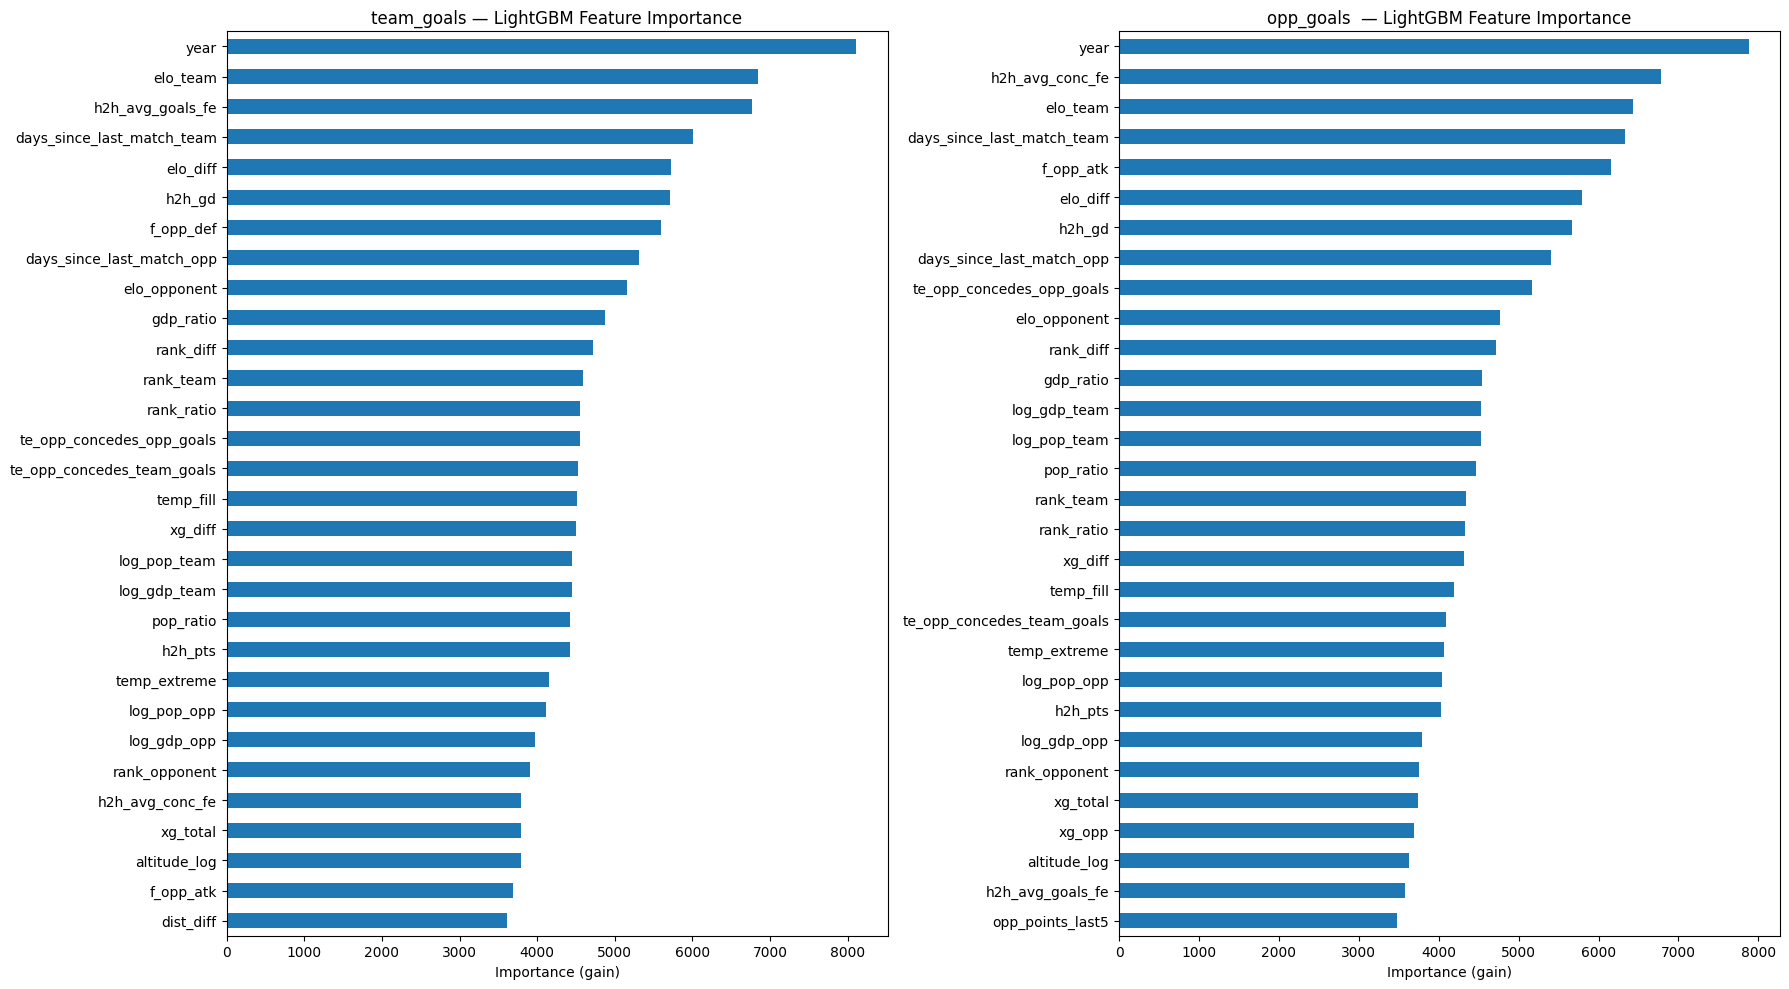

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, model, title in [
    (axes[0], lgb_full_team, "team_goals — LightGBM Feature Importance"),
    (axes[1], lgb_full_opp,  "opp_goals  — LightGBM Feature Importance"),
]:
    imp = pd.Series(
        model.feature_importances_,
        index=FINAL_TRAIN_FEATURES
    ).sort_values(ascending=True).tail(30)
    imp.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Importance (gain)")

plt.tight_layout()
plt.show()


## 10. Predict on Test & Generate Submission

Test team_goals predictions: mean=1.523, std=1.203
Test opp_goals  predictions: mean=1.317, std=0.955


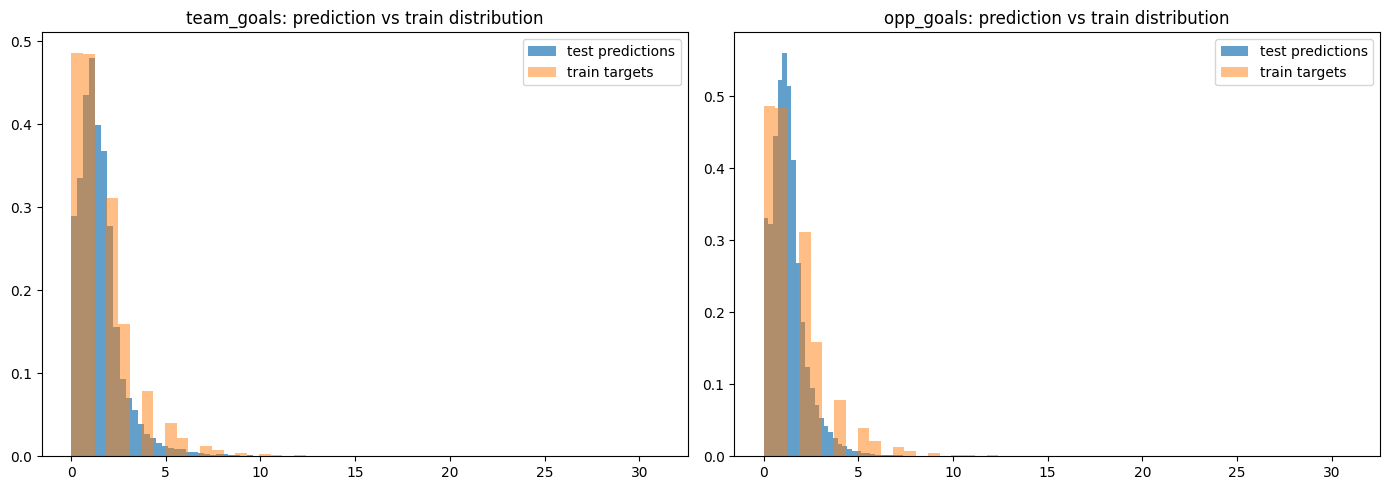

In [18]:
# ================================================================
# Inference pada test set
# ================================================================

X_test = test_fe[FINAL_TRAIN_FEATURES].fillna(-999)

# LightGBM predictions
lgb_pred_team = lgb_full_team.predict(X_test).clip(min=0)
lgb_pred_opp  = lgb_full_opp.predict(X_test).clip(min=0)

# XGBoost predictions
xgb_pred_team = xgb_full_team.predict(X_test).clip(min=0)
xgb_pred_opp  = xgb_full_opp.predict(X_test).clip(min=0)

# Weighted ensemble
final_team = (w_lgb_team * lgb_pred_team + w_xgb_team * xgb_pred_team)
final_opp  = (w_lgb_opp  * lgb_pred_opp  + w_xgb_opp  * xgb_pred_opp)

# Clip to non-negative (goals can't be negative)
final_team = final_team.clip(min=0)
final_opp  = final_opp.clip(min=0)

print(f"Test team_goals predictions: mean={final_team.mean():.3f}, std={final_team.std():.3f}")
print(f"Test opp_goals  predictions: mean={final_opp.mean():.3f}, std={final_opp.std():.3f}")

# ---- Distribution check ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(final_team, bins=50, density=True, alpha=0.7, label="test predictions")
axes[0].hist(train_fe["team_goals"], bins=50, density=True, alpha=0.5, label="train targets")
axes[0].legend()
axes[0].set_title("team_goals: prediction vs train distribution")

axes[1].hist(final_opp, bins=50, density=True, alpha=0.7, label="test predictions")
axes[1].hist(train_fe["opp_goals"], bins=50, density=True, alpha=0.5, label="train targets")
axes[1].legend()
axes[1].set_title("opp_goals: prediction vs train distribution")

plt.tight_layout()
plt.show()


In [19]:
# ================================================================
# Build submission.csv
# Kolom: Id, team_goals, opp_goals
# ================================================================

submission = pd.DataFrame({
    "Id":         test["Id"],
    "team_goals": final_team,
    "opp_goals":  final_opp,
})

submission.to_csv("submission.csv", index=False)

print(f"submission.csv saved: {submission.shape}")
print()
print(submission.head(10).to_string(index=False))


submission.csv saved: (42422, 3)

                 Id  team_goals  opp_goals
 M034984_Seychelles    2.600797   1.264344
  M034984_Mauritius    1.087534   1.412778
    M034985_Comoros    1.968266   1.452037
   M034985_Maldives    1.488910   0.923530
    M034986_Réunion    0.747560   0.579860
 M034986_Madagascar    0.589384   0.897725
M034987_El Salvador    0.972987   1.289674
  M034987_Venezuela    1.609327   1.119578
    M034988_Mayotte    1.240339   2.553502
    M034988_Réunion    2.548567   1.364862


## 11. OOF Error Analysis

In [20]:
# ================================================================
# Analisis error berdasarkan segmen — selaras dengan EDA insight:
# gender, era, dan extremes memiliki karakter berbeda
# ================================================================

val_df = train_fe.loc[covered_idx].copy()
val_df["pred_team"] = lgb_oof_team[covered_idx]
val_df["pred_opp"]  = lgb_oof_opp[covered_idx]
val_df["err_team"]  = (val_df["pred_team"] - val_df["team_goals"]).abs()
val_df["err_opp"]   = (val_df["pred_opp"]  - val_df["opp_goals"]).abs()
val_df["mae_avg"]   = (val_df["err_team"] + val_df["err_opp"]) / 2

print("MAE by Gender:")
print(val_df.groupby("gender")["mae_avg"].mean().round(4))

print("\nMAE by is_home:")
print(val_df.groupby("is_home")["mae_avg"].mean().round(4))

print("\nMAE by neutral:")
print(val_df.groupby("neutral")["mae_avg"].mean().round(4))

print("\nMAE by actual team_goals:")
mae_by_goals = val_df.groupby("team_goals")["err_team"].mean()
print(mae_by_goals.head(8).round(4))

print("\nMAE by Era:")
val_df["era_cat"] = pd.cut(val_df["year"],
    bins=[1870, 1949, 1989, 2000, 2010, 2030],
    labels=["<=1949", "1950-1989", "1990-2000", "2001-2010", "2011+"])
print(val_df.groupby("era_cat")["mae_avg"].mean().round(4))


MAE by Gender:
gender
M    0.6999
W    0.9597
Name: mae_avg, dtype: float64

MAE by is_home:
is_home
0    0.7111
1    0.8031
Name: mae_avg, dtype: float64

MAE by neutral:
neutral
0    0.7299
1    0.8157
Name: mae_avg, dtype: float64

MAE by actual team_goals:
team_goals
0    0.6459
1    0.4901
2    0.6726
3    1.0698
4    1.4614
5    1.7436
6    2.1590
7    2.4757
Name: err_team, dtype: float64

MAE by Era:
era_cat
<=1949          NaN
1950-1989       NaN
1990-2000       NaN
2001-2010    0.7600
2011+        0.7268
Name: mae_avg, dtype: float64


## 12. Summary

| Komponen | Detail |
|---|---|
| **Fitur Rekonstruksi** | ELO, rank, form last-5/10, H2H, days_since |
| **Feature Engineering** | xg_team/opp, elo_win_prob, altitude, distance, gdp_ratio |
| **Target Encoding** | Smoothed (alpha=20) untuk team, tournament, confederation |
| **Model 1** | LightGBM Poisson (`objective='poisson'`) |
| **Model 2** | XGBoost Tweedie (`tweedie_variance_power=1.5`) |
| **Ensemble** | Weighted blending (weight ∝ 1/MAE) |
| **Validasi** | Time-based 3-fold (2-year window each) |
| **Output** | `submission.csv` dengan kolom Id, team_goals, opp_goals |
